# LM Judge Accuracy Evaluation — CLAMBER Dataset

Evaluates whether the LM judge correctly classifies clarifying questions as **EPISTEMIC** or **ALEATORIC**
using 100 entries from the CLAMBER benchmark as ground truth.

## Ground-truth mapping from CLAMBER taxonomy

CLAMBER defines three top-level categories, each with subclasses:

| CLAMBER category | Subclass | Mapped label | Rationale |
|---|---|---|---|
| **FD** — Epistemic Misalignment | `NK` (Unfamiliar entity) | **EPISTEMIC** | Model doesn't recognise the entity — a knowledge gap |
| **FD** — Epistemic Misalignment | `ICL` (Contradiction) | **EPISTEMIC** | Conflicting examples expose a knowledge/reasoning gap |
| **LA** — Linguistic Ambiguity | `polysemy` (Lexical) | **ALEATORIC** | Word has multiple valid meanings — irreducible |
| **LA** — Linguistic Ambiguity | `co-reference` (Semantic) | **ALEATORIC** | Pronoun/reference is ambiguous — context-dependent |
| **MC** — Aleatoric Output | `whom` | **ALEATORIC** | Missing personal/preference details |
| **MC** — Aleatoric Output | `what` | **ALEATORIC** | Missing task-specific details |
| **MC** — Aleatoric Output | `when` | **ALEATORIC** | Missing temporal details |
| **MC** — Aleatoric Output | `where` | **ALEATORIC** | Missing spatial details |

**Input to judge:** `clarifying_question` field (ground-truth CQ from CLAMBER)  
**Target:** 50 epistemic (25 NK + 25 ICL) + 50 aleatoric (mixed MC + LA subclasses)

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../").resolve()))

# ── Dataset config — change DATASET to switch experiments ─────────────────
DATASET           = "clamber"
ROOT              = Path("../").resolve()
DATASETS_DIR      = ROOT / "datasets" / DATASET
OUTPUTS_DIR       = ROOT / "outputs"  / DATASET
PROMPTS_DIR       = ROOT / "prompts"  / "medqa"   # judge instruction is shared

CLAMBER_PATH         = DATASETS_DIR / "clamber_benchmark.jsonl"
JUDGE_INSTRUCTION    = PROMPTS_DIR  / "judge_instruction.txt"
OUTPUT_CSV           = OUTPUTS_DIR  / "clamber_judge_eval.csv"

# ── Sampling config ───────────────────────────────────────────────────────
N_PER_CLASS       = 50      # 50 epistemic + 50 aleatoric = 100 total
RANDOM_SEED       = 42

# ── Model / run config ────────────────────────────────────────────────────
MODEL_ID          = "gemini-2.5-flash"
REQUEST_INTERVAL  = 1.0
# ─────────────────────────────────────────────────────────────────────────

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import json
import logging
import random
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from src.utils import load_dotenv
from src.providers import GeminiProvider
from src.judge import LLMJudge, CSVBatchClassifier, FewShotExample

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)

load_dotenv(ROOT / ".env")
print("Environment loaded.")

Environment loaded.


## Load & Sample CLAMBER

In [3]:
# CLAMBER is double-encoded JSON: each line is a JSON string containing JSON
raw_rows = []
with open(CLAMBER_PATH, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            outer = json.loads(line)
            raw_rows.append(json.loads(outer))

df = pd.DataFrame(raw_rows)
print(f"Total CLAMBER rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print()
print("Subclass counts:")
print(df["subclass"].value_counts())
print()
print("Category counts:")
print(df["category"].value_counts())

Total CLAMBER rows: 3202
Columns: ['question', 'context', 'clarifying_question', 'require_clarification', 'category', 'subclass', 'predict_ambiguous', 'predict_is_ambiguous_response', 'predict_clarifying_question']

Subclass counts:
subclass
none            801
NK              400
ICL             400
co-reference    400
polysemy        400
what            201
whom            200
when            200
where           200
Name: count, dtype: int64

Category counts:
category
MC    1602
FD     800
LA     800
Name: count, dtype: int64


In [4]:
# ── Ground-truth mapping ──────────────────────────────────────────────────
# FD category: NK + ICL → EPISTEMIC
# LA category: polysemy + co-reference → ALEATORIC
# MC category: whom + what + when + where → ALEATORIC
EPISTEMIC_SUBCLASSES = {"NK", "ICL"}
ALEATORIC_SUBCLASSES = {"polysemy", "co-reference", "whom", "what", "when", "where"}

# Only use rows that have a ground-truth clarifying question
has_cq = df["clarifying_question"].notna() & (df["clarifying_question"].str.strip() != "")

epistemic_pool = df[df["subclass"].isin(EPISTEMIC_SUBCLASSES) & has_cq].copy()
aleatoric_pool = df[df["subclass"].isin(ALEATORIC_SUBCLASSES) & has_cq].copy()

print(f"Epistemic pool (NK + ICL): {len(epistemic_pool)}")
print(epistemic_pool["subclass"].value_counts().to_string())
print()
print(f"Aleatoric pool (MC + LA): {len(aleatoric_pool)}")
print(aleatoric_pool["subclass"].value_counts().to_string())

# ── Balanced sampling: 25 NK + 25 ICL for epistemic ──────────────────────
n_each_epi = N_PER_CLASS // 2   # 25 per epistemic subclass

epi_nk  = epistemic_pool[epistemic_pool["subclass"] == "NK"].sample(n=n_each_epi, random_state=RANDOM_SEED)
epi_icl = epistemic_pool[epistemic_pool["subclass"] == "ICL"].sample(n=n_each_epi, random_state=RANDOM_SEED)
epi_sample = pd.concat([epi_nk, epi_icl], ignore_index=True)

# 50 aleatoric drawn proportionally across subclasses
ale_sample = aleatoric_pool.sample(n=N_PER_CLASS, random_state=RANDOM_SEED)

epi_sample = epi_sample.copy()
ale_sample = ale_sample.copy()
epi_sample["true_label"] = "EPISTEMIC"
ale_sample["true_label"] = "ALEATORIC"

eval_df = pd.concat([epi_sample, ale_sample], ignore_index=True).sample(
    frac=1, random_state=RANDOM_SEED   # shuffle
).reset_index(drop=True)

eval_df["eval_id"] = [f"clamber_{i:03d}" for i in range(len(eval_df))]

print(f"\nEvaluation set: {len(eval_df)} rows")
print("\nSubclass distribution in eval set:")
print(eval_df.groupby(["true_label", "subclass"]).size().to_string())
print()
print(eval_df[["eval_id", "subclass", "true_label", "clarifying_question"]].head(10).to_string(index=False))

Epistemic pool (NK + ICL): 400
subclass
NK     200
ICL    200

Aleatoric pool (MC + LA): 1201
subclass
what            201
whom            200
when            200
where           200
co-reference    200
polysemy        200

Evaluation set: 100 rows

Subclass distribution in eval set:
true_label  subclass    
ALEATORIC   co-reference     4
            polysemy         6
            what            12
            when            10
            where           12
            whom             6
EPISTEMIC   ICL             25
            NK              25

    eval_id subclass true_label                                                                                                clarifying_question
clamber_000    where  ALEATORIC                                                                                     Which one: country, or states?
clamber_001     whom  ALEATORIC      What factors are most important to you in a job, such as salary, location, career growth, or company culture?


## Run LM Judge

## Few-Shot Examples

Six examples chosen to target the three failure modes from the baseline run:

| Failure mode | Baseline accuracy | Pattern | Fix |
|---|---|---|---|
| `ICL` (EPISTEMIC) | 32% | "Is the category either X or Y?" read as aleatoric | Show that binary-option CQs can be epistemic when the model is resolving a contradiction |
| `co-reference` (ALEATORIC) | 0% | "What does she refer to? X or Y?" read as epistemic | Show that pronoun disambiguation is aleatoric — the referent is context-dependent, not a knowable fact |
| `when/what` (ALEATORIC) | ~65% | "Which year/episode: X, Y, Z?" read as epistemic | Show that multi-option CQs asking the user to choose between items are aleatoric |

In [5]:
FEW_SHOT_EXAMPLES = [
    # ── EPISTEMIC: NK — model encounters a completely unknown entity ────────
    FewShotExample(
        input="What is the context or field in which 'Comallcium' is typically used or referenced?",
        expected_output="EPISTEMIC",
        explanation=(
            "The model has never encountered this entity and is asking for information "
            "to fill a specific knowledge gap. A definitive answer exists — once the user "
            "provides context the uncertainty is completely resolved."
        ),
    ),
    # ── EPISTEMIC: ICL — model hits contradictory examples in the query ────
    FewShotExample(
        input="Is the category either animal or outdoor location?",
        expected_output="EPISTEMIC",
        explanation=(
            "The query contains examples that contradict each other under any single "
            "category rule the model knows. The binary phrasing does NOT mean multiple "
            "valid answers exist — it means the model cannot reconcile the contradiction "
            "with its knowledge. There is one correct categorisation; the model simply "
            "cannot determine it. This is a knowledge/reasoning gap, not a preference gap."
        ),
    ),
    # ── EPISTEMIC: ICL variant — same pattern, different domain ───────────
    FewShotExample(
        input="Is the category either religious leader or male pronoun?",
        expected_output="EPISTEMIC",
        explanation=(
            "Same ICL pattern: the model is exposing an internal contradiction it cannot "
            "resolve. The two options are not equally valid user preferences — one is the "
            "correct answer according to the underlying rule, and the model lacks the "
            "knowledge to determine which."
        ),
    ),
    # ── ALEATORIC: co-reference — pronoun with no resolvable referent ──────
    FewShotExample(
        input="What does she refer to? the sister-in-law or Amanda?",
        expected_output="ALEATORIC",
        explanation=(
            "The pronoun 'she' could validly refer to either person. This is NOT a "
            "knowledge gap — no additional fact or training data can determine the "
            "correct referent. Only the user's original conversational context can "
            "resolve it, making this irreducibly ambiguous."
        ),
    ),
    # ── ALEATORIC: MC/when — user must choose between valid time options ───
    FewShotExample(
        input="Which year: 1984, 1985, 1998, 2004, or 2009?",
        expected_output="ALEATORIC",
        explanation=(
            "The query is underspecified across multiple valid years. The model is "
            "asking the user to select which version or instance they mean — all "
            "options are equally valid. No external fact can determine which year "
            "the user intends; only the user can resolve this."
        ),
    ),
    # ── ALEATORIC: MC/whom — answer depends on personal preference ─────────
    FewShotExample(
        input="What factors are most important to you in a job, such as salary, location, career growth, or company culture?",
        expected_output="ALEATORIC",
        explanation=(
            "The correct answer depends entirely on the individual user's preferences. "
            "No fact, no training data, and no amount of knowledge can resolve this — "
            "it is inherently personal and has many equally valid answers."
        ),
    ),
]

print(f"Defined {len(FEW_SHOT_EXAMPLES)} few-shot examples.")

Defined 6 few-shot examples.


In [6]:
# Save the eval set as the input CSV for the batch classifier
INPUT_CSV = OUTPUTS_DIR / "clamber_eval_input.csv"
eval_df[["eval_id", "subclass", "true_label", "clarifying_question"]].to_csv(
    INPUT_CSV, index=False
)
print(f"Eval input saved to {INPUT_CSV}")

Eval input saved to D:\final_project\pilot_study\outputs\clamber\clamber_eval_input.csv


In [7]:
OUTPUT_CSV_FEWSHOT = OUTPUTS_DIR / "clamber_judge_eval_fewshot.csv"
REGENERATE = False  # set True to re-run from scratch

if OUTPUT_CSV_FEWSHOT.exists() and not REGENERATE:
    print(f"Loading existing few-shot results from {OUTPUT_CSV_FEWSHOT}")
else:
    if REGENERATE and OUTPUT_CSV_FEWSHOT.exists():
        OUTPUT_CSV_FEWSHOT.unlink()
        print("Deleted existing output — regenerating.")

    provider = GeminiProvider(model_id=MODEL_ID)

    judge = LLMJudge(
        provider=provider,
        instructions_path=JUDGE_INSTRUCTION,
        few_shot_examples=FEW_SHOT_EXAMPLES,
        label_parser=lambda text: text.strip().upper(),
    )

    classifier = CSVBatchClassifier(
        judge=judge,
        input_csv=INPUT_CSV,
        output_csv=OUTPUT_CSV_FEWSHOT,
        question_column="clarifying_question",
        id_column="eval_id",
        delay_between_calls=REQUEST_INTERVAL,
    )

    classifier.run()
    print(f"Classification complete. Results at {OUTPUT_CSV_FEWSHOT}")

Loading existing few-shot results from D:\final_project\pilot_study\outputs\clamber\clamber_judge_eval_fewshot.csv


## Accuracy Analysis

In [8]:
def compute_accuracy(results_path, label=""):
    results_df = pd.read_csv(results_path)
    merged = eval_df[["eval_id", "subclass", "true_label", "clarifying_question"]].merge(
        results_df[["id", "label", "latency_seconds", "error"]].rename(columns={"id": "eval_id"}),
        on="eval_id", how="left",
    )
    merged["predicted_label"] = merged["label"].str.strip().str.upper()
    merged["valid_prediction"] = merged["predicted_label"].isin({"EPISTEMIC", "ALEATORIC"})
    merged["correct"] = merged["true_label"] == merged["predicted_label"]
    return merged

baseline   = compute_accuracy(OUTPUT_CSV,         label="Baseline")
fewshot    = compute_accuracy(OUTPUT_CSV_FEWSHOT,  label="Few-shot")

def summary(df):
    v = df[df["valid_prediction"]]
    return {
        "total": len(df),
        "valid": len(v),
        "correct": int(v["correct"].sum()),
        "accuracy": v["correct"].mean(),
    }

b, f = summary(baseline), summary(fewshot)
display(Markdown(f"""
### Overall Results

| Metric | Baseline (0-shot) | Few-shot (6 examples) | Δ |
|---|---|---|---|
| Total | {b['total']} | {f['total']} | — |
| Valid predictions | {b['valid']} | {f['valid']} | — |
| Correct | {b['correct']} | {f['correct']} | {f['correct']-b['correct']:+d} |
| **Accuracy** | **{b['accuracy']:.1%}** | **{f['accuracy']:.1%}** | **{f['accuracy']-b['accuracy']:+.1%}** |
"""))

# Per-class
print("Per-class accuracy:")
for label, name in [(baseline, "Baseline"), (fewshot, "Few-shot")]:
    v = label[label["valid_prediction"]]
    pc = v.groupby("true_label")["correct"].mean().map("{:.1%}".format)
    print(f"  {name}: {pc.to_dict()}")

# Per-subclass comparison
print("\nPer-subclass accuracy (Baseline → Few-shot):")
sub_b = baseline[baseline["valid_prediction"]].groupby(["true_label","subclass"])["correct"].mean()
sub_f = fewshot[fewshot["valid_prediction"]].groupby(["true_label","subclass"])["correct"].mean()
comp = pd.DataFrame({"baseline": sub_b, "fewshot": sub_f})
comp["delta"] = comp["fewshot"] - comp["baseline"]
comp["baseline"] = comp["baseline"].map("{:.1%}".format)
comp["fewshot"]  = comp["fewshot"].map("{:.1%}".format)
comp["delta"]    = comp["delta"].map("{:+.1%}".format)
display(comp)


### Overall Results

| Metric | Baseline (0-shot) | Few-shot (6 examples) | Δ |
|---|---|---|---|
| Total | 100 | 100 | — |
| Valid predictions | 100 | 100 | — |
| Correct | 67 | 98 | +31 |
| **Accuracy** | **67.0%** | **98.0%** | **+31.0%** |


Per-class accuracy:
  Baseline: {'ALEATORIC': '68.0%', 'EPISTEMIC': '66.0%'}
  Few-shot: {'ALEATORIC': '96.0%', 'EPISTEMIC': '100.0%'}

Per-subclass accuracy (Baseline → Few-shot):


baseline fewshot    delta
true_label subclass                              
ALEATORIC  co-reference     0.0%  100.0%  +100.0%
           polysemy        66.7%  100.0%   +33.3%
           what            75.0%   91.7%   +16.7%
           when            60.0%  100.0%   +40.0%
           where           75.0%   91.7%   +16.7%
           whom           100.0%  100.0%    +0.0%
EPISTEMIC  ICL             32.0%  100.0%   +68.0%
           NK             100.0%  100.0%    +0.0%

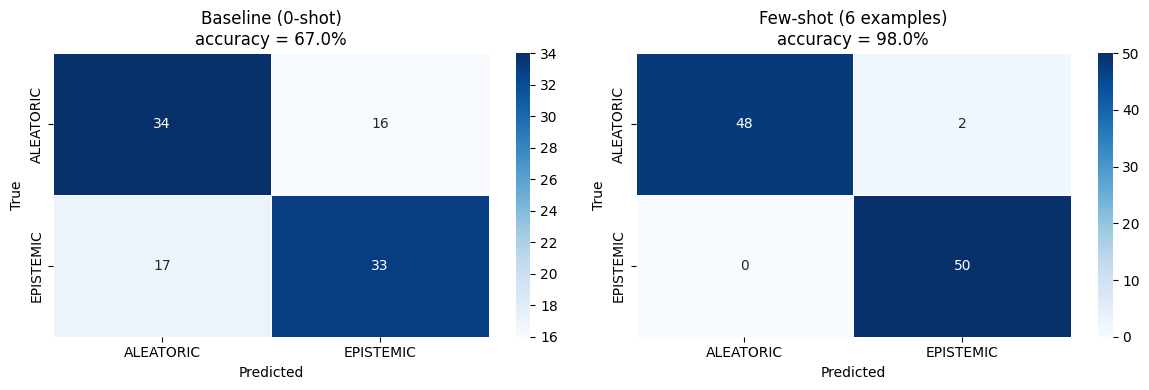

Saved to D:\final_project\pilot_study\outputs\clamber\confusion_comparison.png


In [9]:
# ── Side-by-side confusion matrices ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title, fname in [
    (axes[0], baseline,  f"Baseline (0-shot)\naccuracy = {summary(baseline)['accuracy']:.1%}",  "confusion_baseline.png"),
    (axes[1], fewshot,   f"Few-shot (6 examples)\naccuracy = {summary(fewshot)['accuracy']:.1%}", "confusion_fewshot.png"),
]:
    valid = df[df["valid_prediction"]]
    cm = pd.crosstab(valid["true_label"], valid["predicted_label"],
                     rownames=["True"], colnames=["Predicted"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, linewidths=0.5)
    ax.set_title(title)

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "confusion_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {OUTPUTS_DIR / 'confusion_comparison.png'}")

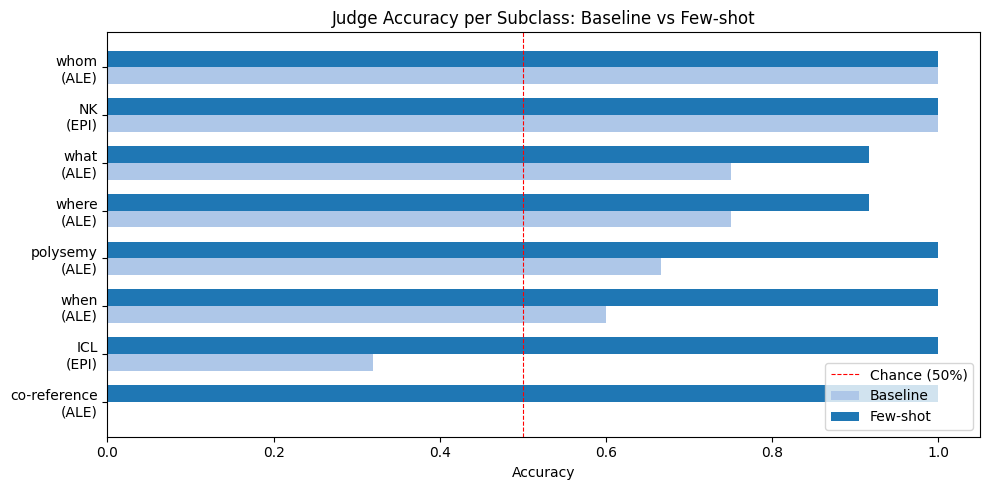

In [10]:
# ── Per-subclass accuracy: Baseline vs Few-shot ───────────────────────────
sub_b = (baseline[baseline["valid_prediction"]]
         .groupby(["subclass","true_label"])["correct"].mean().reset_index()
         .rename(columns={"correct":"accuracy"}))
sub_b["run"] = "Baseline"

sub_f = (fewshot[fewshot["valid_prediction"]]
         .groupby(["subclass","true_label"])["correct"].mean().reset_index()
         .rename(columns={"correct":"accuracy"}))
sub_f["run"] = "Few-shot"

plot_df = pd.concat([sub_b, sub_f]).sort_values(["true_label","subclass","run"])
palette  = {"Baseline": "#aec7e8", "Few-shot": "#1f77b4"}

fig, ax = plt.subplots(figsize=(10, 5))
x_labels = [f"{r['subclass']}\n({r['true_label'][:3]})" for _, r in
            sub_b.sort_values("accuracy").iterrows()]
# grouped barh
bar_data = plot_df.pivot_table(index=["subclass","true_label"], columns="run",
                                values="accuracy").reset_index()
bar_data["label"] = bar_data["subclass"] + "\n(" + bar_data["true_label"].str[:3] + ")"
bar_data = bar_data.sort_values("Baseline")

y = range(len(bar_data))
height = 0.35
ax.barh([i - height/2 for i in y], bar_data["Baseline"], height=height,
        color="#aec7e8", label="Baseline")
ax.barh([i + height/2 for i in y], bar_data["Few-shot"], height=height,
        color="#1f77b4", label="Few-shot")
ax.set_yticks(list(y))
ax.set_yticklabels(bar_data["label"].tolist())
ax.axvline(0.5, color="red", linestyle="--", linewidth=0.8, label="Chance (50%)")
ax.set_xlabel("Accuracy")
ax.set_title("Judge Accuracy per Subclass: Baseline vs Few-shot")
ax.set_xlim(0, 1.05)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "accuracy_per_subclass_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ── Error inspection — few-shot: where does the judge still go wrong? ────
n_valid_fs = int(fewshot["valid_prediction"].sum())
errors = fewshot[fewshot["valid_prediction"] & ~fewshot["correct"]].copy()
print(f"Misclassified (few-shot): {len(errors)} / {n_valid_fs}")

if len(errors) > 0:
    display(Markdown("### Misclassified examples (few-shot)"))
    display(
        errors[["eval_id", "subclass", "true_label", "predicted_label", "clarifying_question"]]
        .head(20)
        .to_string(index=False)
    )

Misclassified (few-shot): 2 / 100


### Misclassified examples (few-shot)

'    eval_id subclass true_label predicted_label                            clarifying_question\nclamber_062    where  ALEATORIC       EPISTEMIC  Which, origin: Greek μελανία, or Greek μέλας?\nclamber_096     what  ALEATORIC       EPISTEMIC Which one: a process, or an performing enzyme?'

## Reflection

### Overall accuracy — does the judge perform above chance?
_Your notes here._

### Which subclasses are hardest for the judge and why?
_Your notes here._

### NK vs ICL — does the judge handle both epistemic subtypes equally well?
_Your notes here._

### Where does the judge confuse epistemic for aleatoric or vice versa?
_Your notes here._

### What does this tell us about the judge instruction quality?
_Your notes here._